In [1]:
"""
# 3D MicroCT Subvolume Analysis: Porosity, Region Statistics and Morphological Classification

This notebook analyzes a real 3D microCT subvolume extracted from a mortar sample.

The workflow includes:

1. Loading a stack of cropped microCT slices.
2. Inspecting representative slices.
3. Visualizing orthogonal views.
4. Preprocessing and intensity normalization.
5. Segmenting pores and resin-like regions.
6. Computing slice-by-slice phase fractions.
7. Measuring 3D connected components.
8. Extracting statistical and morphological descriptors.
9. Classifying regions based on intensity and shape features.

The main goal is to transform a 3D microCT image stack into quantitative scientific measurements.

## Dataset description

The dataset consists of a cropped 3D subvolume extracted from a larger cylindrical microCT scan of a mortar sample.

The cropped subvolume contains hundreds of consecutive 2D slices. Each slice corresponds to the same region of interest across the depth of the sample.

Expected volume size:

- X direction: approximately 202 pixels
- Y direction: approximately 178 pixels
- Z direction: approximately 435 slices

The images are stored as TIFF files in:

"data/raw/DatosSubV"

This subvolume is small enough to be processed in memory, but large enough to allow real 3D quantitative analysis.
"""

'\n# 3D MicroCT Subvolume Analysis: Porosity, Region Statistics and Morphological Classification\n\nThis notebook analyzes a real 3D microCT subvolume extracted from a mortar sample.\n\nThe workflow includes:\n\n1. Loading a stack of cropped microCT slices.\n2. Inspecting representative slices.\n3. Visualizing orthogonal views.\n4. Preprocessing and intensity normalization.\n5. Segmenting pores and resin-like regions.\n6. Computing slice-by-slice phase fractions.\n7. Measuring 3D connected components.\n8. Extracting statistical and morphological descriptors.\n9. Classifying regions based on intensity and shape features.\n\nThe main goal is to transform a 3D microCT image stack into quantitative scientific measurements.\n\n## Dataset description\n\nThe dataset consists of a cropped 3D subvolume extracted from a larger cylindrical microCT scan of a mortar sample.\n\nThe cropped subvolume contains hundreds of consecutive 2D slices. Each slice corresponds to the same region of interest acr

In [2]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from skimage import io
from skimage import exposure
from skimage import filters
from skimage import morphology
from skimage import measure
from skimage import segmentation
from skimage import util

from scipy import ndimage as ndi

In [3]:
# ============================================================
# Project paths
# ============================================================

PROJECT_DIR = Path("..").resolve()

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw" / "DatosSubV"
PROCESSED_DIR = DATA_DIR / "processed"

FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
REPORTS_DIR = PROJECT_DIR / "reports"

# Create output directories if they do not exist
for path in [PROCESSED_DIR, FIGURES_DIR, RESULTS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Raw data directory:", RAW_DIR)
print("Figures directory:", FIGURES_DIR)
print("Results directory:", RESULTS_DIR)

Project directory: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis
Raw data directory: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\data\raw\DatosSubV
Figures directory: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures
Results directory: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results


In [4]:
# ============================================================
# Check raw data directory
# ============================================================

if not RAW_DIR.exists():
    raise FileNotFoundError(f"Raw data directory not found: {RAW_DIR}")

print("Raw data directory found.")

Raw data directory found.


In [7]:
# ============================================================
# List TIFF files
# ============================================================

tif_files = sorted(
    list(RAW_DIR.glob("*.tif")) + 
    list(RAW_DIR.glob("*.tiff"))
)

print(f"Number of TIFF files found: {len(tif_files)}")

if len(tif_files) == 0:
    raise FileNotFoundError("No TIFF files were found in the raw data directory.")

print("First 5 files:")
for file in tif_files[:5]:
    print(" ", file.name)

print("\nLast 5 files:")
for file in tif_files[-5:]:
    print(" ", file.name)

Number of TIFF files found: 435
First 5 files:
  DatosSubV0000.tif
  DatosSubV0001.tif
  DatosSubV0002.tif
  DatosSubV0003.tif
  DatosSubV0004.tif

Last 5 files:
  DatosSubV0430.tif
  DatosSubV0431.tif
  DatosSubV0432.tif
  DatosSubV0433.tif
  DatosSubV0434.tif


In [8]:
# ============================================================
# Load one representative slice
# ============================================================

middle_index = len(tif_files) // 2
sample_path = tif_files[middle_index]

sample_slice = io.imread(sample_path)

print("Representative slice:")
print("File:", sample_path.name)
print("Shape:", sample_slice.shape)
print("Data type:", sample_slice.dtype)
print("Min intensity:", sample_slice.min())
print("Max intensity:", sample_slice.max())
print("Mean intensity:", sample_slice.mean())

Representative slice:
File: DatosSubV0217.tif
Shape: (178, 202)
Data type: uint8
Min intensity: 19
Max intensity: 255
Mean intensity: 185.14717988652797


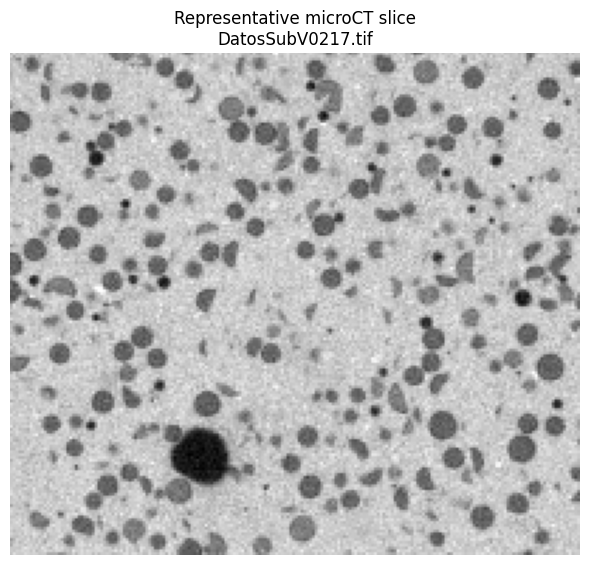

In [9]:
# ============================================================
# Display representative slice
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(sample_slice, cmap="gray")
ax.set_title(f"Representative microCT slice\n{sample_path.name}")
ax.axis("off")

plt.tight_layout()
plt.show()

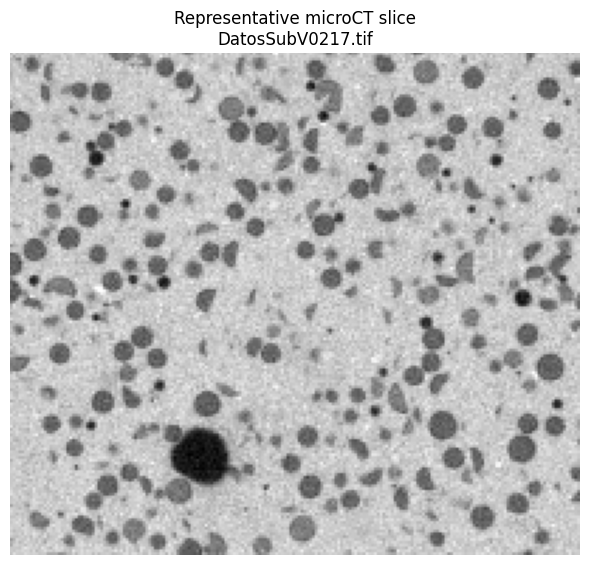

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\representative_slice.png


In [10]:
# ============================================================
# Save representative slice figure
# ============================================================

out_path = FIGURES_DIR / "representative_slice.png"

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(sample_slice, cmap="gray")
ax.set_title(f"Representative microCT slice\n{sample_path.name}")
ax.axis("off")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [11]:
# ============================================================
# Load full microCT stack as a 3D NumPy array
# ============================================================

volume_slices = []

for file in tif_files:
    img = io.imread(file)
    volume_slices.append(img)

volume = np.stack(volume_slices, axis=0)

print("Volume loaded successfully.")
print("Volume shape (Z, Y, X):", volume.shape)
print("Data type:", volume.dtype)
print("Min intensity:", volume.min())
print("Max intensity:", volume.max())
print("Mean intensity:", volume.mean())

Volume loaded successfully.
Volume shape (Z, Y, X): (435, 178, 202)
Data type: uint8
Min intensity: 7
Max intensity: 255
Mean intensity: 185.01312331930598


In [12]:
# ============================================================
# Check expected volume dimensions
# ============================================================

z_size, y_size, x_size = volume.shape

print(f"Z slices: {z_size}")
print(f"Y pixels: {y_size}")
print(f"X pixels: {x_size}")

expected_y = 178
expected_x = 202

if y_size == expected_y and x_size == expected_x:
    print("Slice dimensions match the expected cropped subvolume size.")
else:
    print("Warning: slice dimensions are different from the expected size.")

Z slices: 435
Y pixels: 178
X pixels: 202
Slice dimensions match the expected cropped subvolume size.


In [13]:
# ============================================================
# Physical metadata
# ============================================================

VOXEL_SIZE_UM = 20.0*4

voxel_size_mm = VOXEL_SIZE_UM / 1000.0
voxel_volume_mm3 = voxel_size_mm ** 3

physical_size_z_mm = z_size * voxel_size_mm
physical_size_y_mm = y_size * voxel_size_mm
physical_size_x_mm = x_size * voxel_size_mm

print("Voxel size:")
print(f"  {VOXEL_SIZE_UM:.2f} µm")
print(f"  {voxel_size_mm:.4f} mm")

print("\nVoxel volume:")
print(f"  {voxel_volume_mm3:.8f} mm³")

print("\nPhysical subvolume size:")
print(f"  Z: {physical_size_z_mm:.2f} mm")
print(f"  Y: {physical_size_y_mm:.2f} mm")
print(f"  X: {physical_size_x_mm:.2f} mm")

print("\nTotal analyzed volume:")
total_volume_mm3 = volume.size * voxel_volume_mm3
print(f"  {total_volume_mm3:.4f} mm³")

Voxel size:
  80.00 µm
  0.0800 mm

Voxel volume:
  0.00051200 mm³

Physical subvolume size:
  Z: 34.80 mm
  Y: 14.24 mm
  X: 16.16 mm

Total analyzed volume:
  8008.1203 mm³


In [14]:
# ============================================================
# Global intensity statistics
# ============================================================

intensity_stats = {
    "min": np.min(volume),
    "max": np.max(volume),
    "mean": np.mean(volume),
    "median": np.median(volume),
    "std": np.std(volume),
    "p01": np.percentile(volume, 1),
    "p05": np.percentile(volume, 5),
    "p25": np.percentile(volume, 25),
    "p75": np.percentile(volume, 75),
    "p95": np.percentile(volume, 95),
    "p99": np.percentile(volume, 99),
}

df_intensity_stats = pd.DataFrame([intensity_stats])

df_intensity_stats

,min,max,mean,median,std,p01,p05,p25,p75,p95,p99
0,7,255,185.013123,198.0,36.038782,79.0,108.0,177.0,208.0,221.0,230.0


In [15]:
# ============================================================
# Save global intensity statistics
# ============================================================

out_csv = RESULTS_DIR / "global_intensity_statistics.csv"

df_intensity_stats.to_csv(out_csv, index=False)

print(f"Global intensity statistics saved to: {out_csv}")

Global intensity statistics saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\global_intensity_statistics.csv


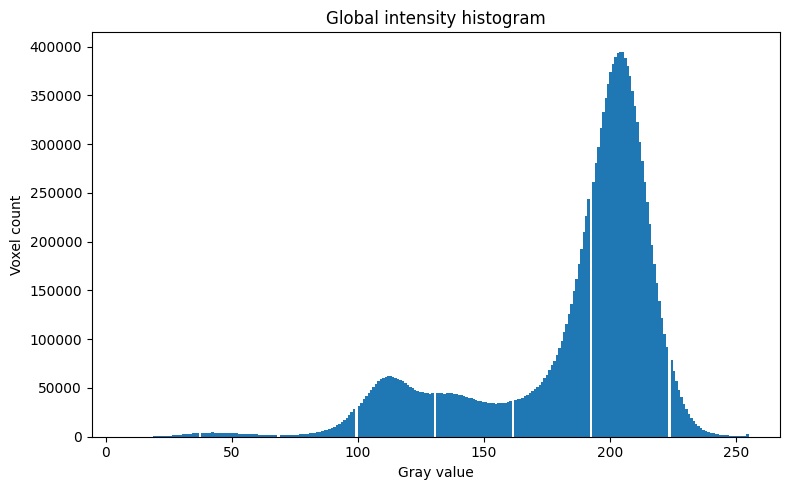

In [16]:
# ============================================================
# Global intensity histogram
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(volume.ravel(), bins=256)
ax.set_title("Global intensity histogram")
ax.set_xlabel("Gray value")
ax.set_ylabel("Voxel count")

plt.tight_layout()
plt.show()

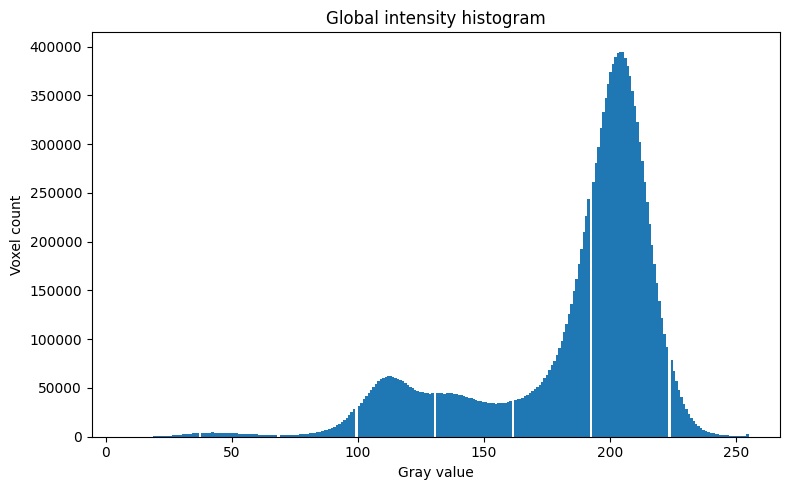

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\global_intensity_histogram.png


In [17]:
# ============================================================
# Save global intensity histogram
# ============================================================

out_path = FIGURES_DIR / "global_intensity_histogram.png"

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(volume.ravel(), bins=256)
ax.set_title("Global intensity histogram")
ax.set_xlabel("Gray value")
ax.set_ylabel("Voxel count")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

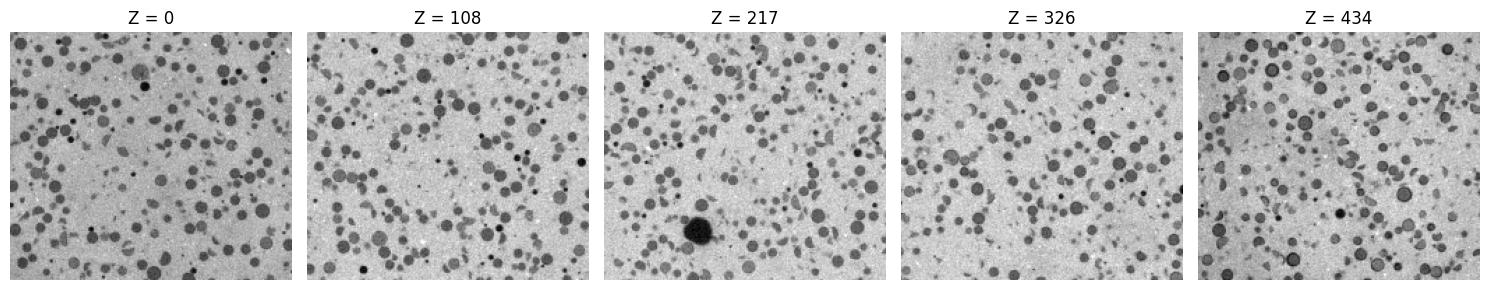

In [18]:
# ============================================================
# Display representative slices along Z
# ============================================================

slice_indices = [
    0,
    z_size // 4,
    z_size // 2,
    3 * z_size // 4,
    z_size - 1
]

fig, axes = plt.subplots(1, len(slice_indices), figsize=(15, 4))

for ax, idx in zip(axes, slice_indices):
    ax.imshow(volume[idx], cmap="gray")
    ax.set_title(f"Z = {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\representative_z_slices.png


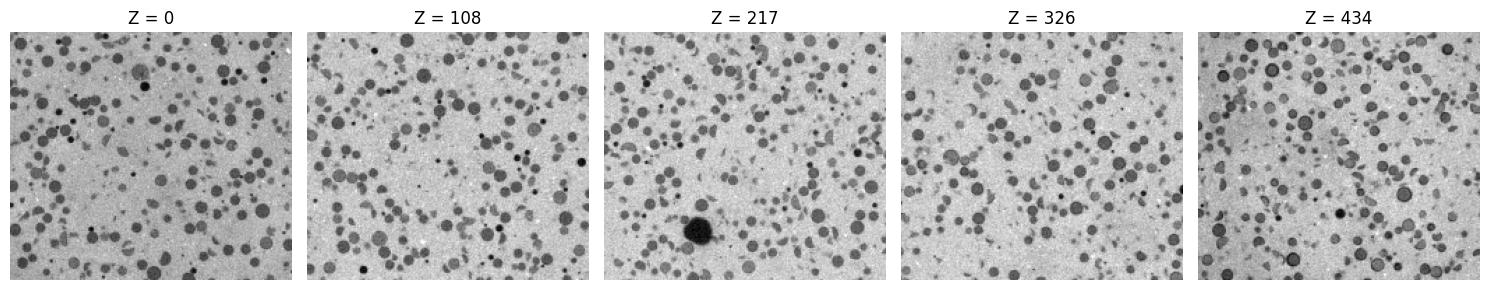

In [19]:
# ============================================================
# Save representative Z slices
# ============================================================

out_path = FIGURES_DIR / "representative_z_slices.png"

fig, axes = plt.subplots(1, len(slice_indices), figsize=(15, 4))

for ax, idx in zip(axes, slice_indices):
    ax.imshow(volume[idx], cmap="gray")
    ax.set_title(f"Z = {idx}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
#plt.show()

print(f"Figure saved to: {out_path}")

In [20]:
# ============================================================
# Detailed intensity percentiles
# ============================================================

percentiles = [0, 1, 2, 5, 10, 25, 50, 75, 90, 95, 98, 99, 100]

intensity_percentiles = {
    f"p{p:02d}" if p < 100 else "p100": np.percentile(volume, p)
    for p in percentiles
}

df_percentiles = pd.DataFrame(
    list(intensity_percentiles.items()),
    columns=["percentile", "gray_value"]
)

df_percentiles

,percentile,gray_value
0,p00,7.0
1,p01,79.0
2,p02,97.0
3,p05,108.0
4,p10,122.0
5,p25,177.0
6,p50,198.0
7,p75,208.0
8,p90,216.0
9,p95,221.0


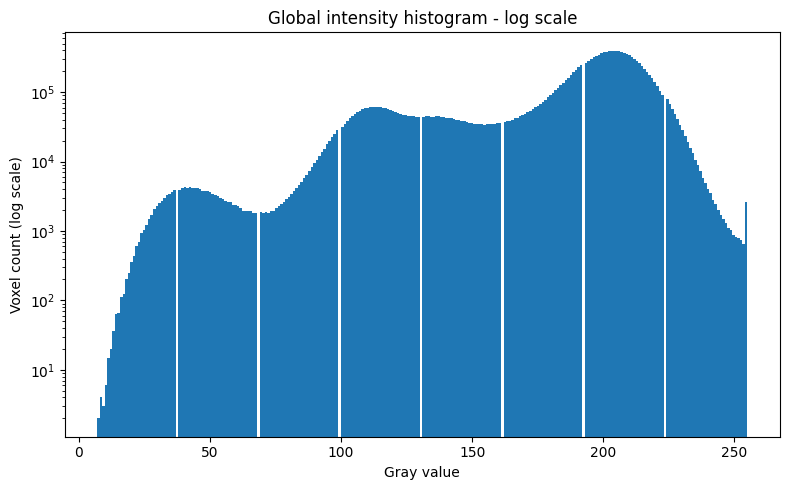

In [21]:
# ============================================================
# Global intensity histogram with logarithmic y-axis
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(volume.ravel(), bins=256)
ax.set_yscale("log")

ax.set_title("Global intensity histogram - log scale")
ax.set_xlabel("Gray value")
ax.set_ylabel("Voxel count (log scale)")

plt.tight_layout()
plt.show()

XY view shape: (178, 202)
XZ view shape: (435, 202)
YZ view shape: (435, 178)


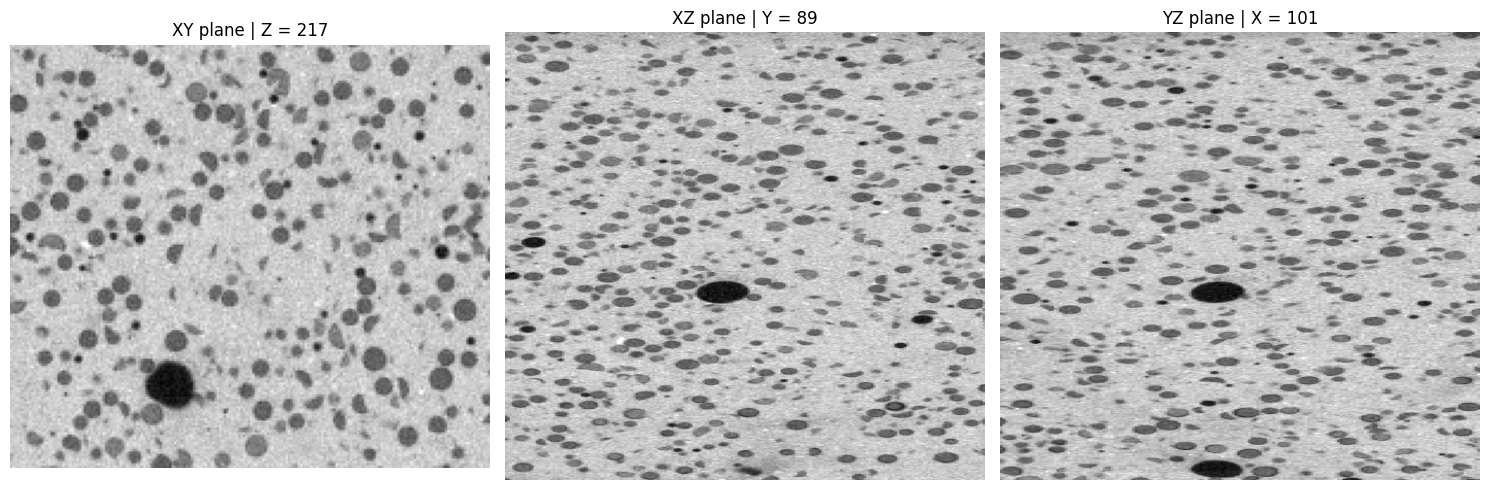

In [22]:
# ============================================================
# Orthogonal views: XY, XZ, YZ
# ============================================================

z_mid = z_size // 2
y_mid = y_size // 2
x_mid = x_size // 2

xy_view = volume[z_mid, :, :]
xz_view = volume[:, y_mid, :]
yz_view = volume[:, :, x_mid]

print("XY view shape:", xy_view.shape)
print("XZ view shape:", xz_view.shape)
print("YZ view shape:", yz_view.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(xy_view, cmap="gray")
axes[0].set_title(f"XY plane | Z = {z_mid}")
axes[0].axis("off")

axes[1].imshow(xz_view, cmap="gray", aspect="auto")
axes[1].set_title(f"XZ plane | Y = {y_mid}")
axes[1].axis("off")

axes[2].imshow(yz_view, cmap="gray", aspect="auto")
axes[2].set_title(f"YZ plane | X = {x_mid}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

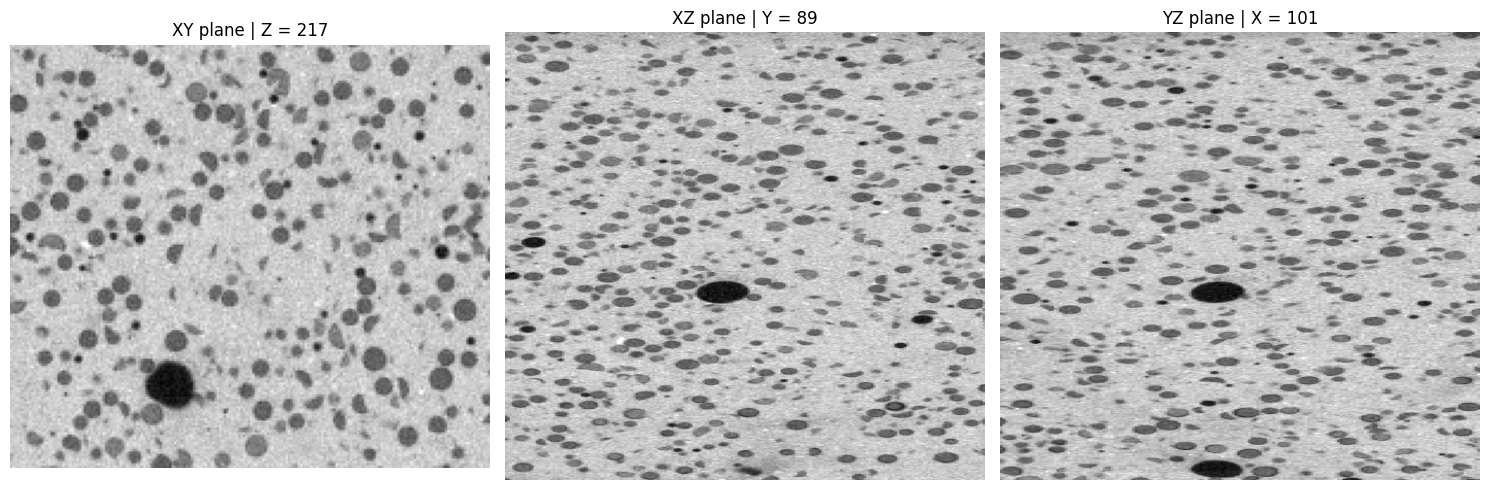

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\orthogonal_views_xy_xz_yz.png


In [23]:
# ============================================================
# Save orthogonal views
# ============================================================

out_path = FIGURES_DIR / "orthogonal_views_xy_xz_yz.png"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(xy_view, cmap="gray")
axes[0].set_title(f"XY plane | Z = {z_mid}")
axes[0].axis("off")

axes[1].imshow(xz_view, cmap="gray", aspect="auto")
axes[1].set_title(f"XZ plane | Y = {y_mid}")
axes[1].axis("off")

axes[2].imshow(yz_view, cmap="gray", aspect="auto")
axes[2].set_title(f"YZ plane | X = {x_mid}")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

Robust contrast limits:
  p01 = 79.00
  p99 = 230.00


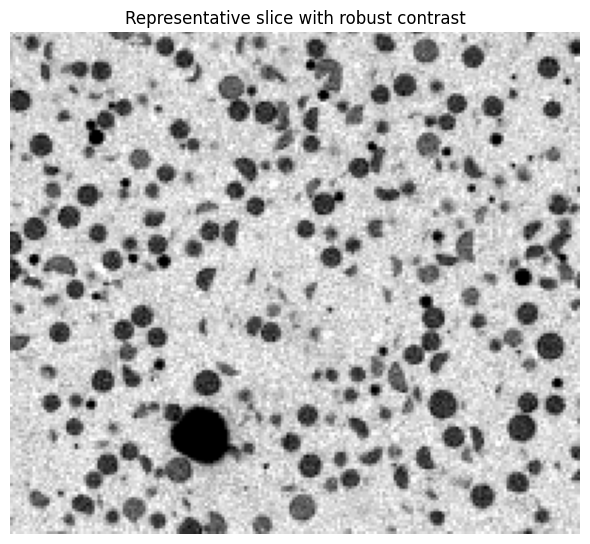

In [28]:
# ============================================================
# Robust contrast visualization
# ============================================================

p_low, p_high = np.percentile(volume, [1, 99])

print(f"Robust contrast limits:")
print(f"  p01 = {p_low:.2f}")
print(f"  p99 = {p_high:.2f}")

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(sample_slice, cmap="gray", vmin=p_low, vmax=p_high)
ax.set_title("Representative slice with robust contrast")
ax.axis("off")

plt.tight_layout()
plt.show()

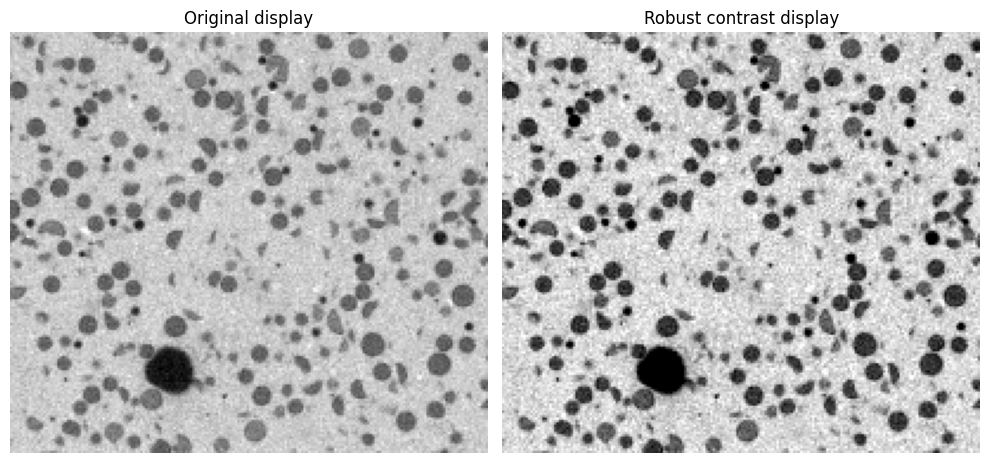

In [29]:
# ============================================================
# Original vs robust contrast comparison
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sample_slice, cmap="gray")
axes[0].set_title("Original display")
axes[0].axis("off")

axes[1].imshow(sample_slice, cmap="gray", vmin=p_low, vmax=p_high)
axes[1].set_title("Robust contrast display")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# Initial intensity thresholds for exploratory segmentation
# ============================================================

# Based on the global percentiles and visual inspection:
# p05 ~ 108
# p25 ~ 177
# p50 ~ 198

PORE_THRESHOLD = 105
INTERMEDIATE_THRESHOLD = 175

print("Initial segmentation thresholds:")
print(f"  Pores / very dark regions: intensity < {PORE_THRESHOLD}")
print(f"  Intermediate dark regions: {PORE_THRESHOLD} <= intensity < {INTERMEDIATE_THRESHOLD}")
print(f"  Bright matrix: intensity >= {INTERMEDIATE_THRESHOLD}")

Initial segmentation thresholds:
  Pores / very dark regions: intensity < 105
  Intermediate dark regions: 105 <= intensity < 175
  Bright matrix: intensity >= 175


In [31]:
# ============================================================
# Create initial 3D masks
# ============================================================

pores_mask = volume < PORE_THRESHOLD

intermediate_mask = (volume >= PORE_THRESHOLD) & (volume < INTERMEDIATE_THRESHOLD)

matrix_mask = volume >= INTERMEDIATE_THRESHOLD

print("Mask shapes:")
print("  pores_mask:", pores_mask.shape)
print("  intermediate_mask:", intermediate_mask.shape)
print("  matrix_mask:", matrix_mask.shape)

print("\nVoxel counts:")
print("  pores:", pores_mask.sum())
print("  intermediate:", intermediate_mask.sum())
print("  matrix:", matrix_mask.sum())

print("\nVolume fractions:")
print(f"  pores: {pores_mask.mean():.4f}")
print(f"  intermediate: {intermediate_mask.mean():.4f}")
print(f"  matrix: {matrix_mask.mean():.4f}")

Mask shapes:
  pores_mask: (435, 178, 202)
  intermediate_mask: (435, 178, 202)
  matrix_mask: (435, 178, 202)

Voxel counts:
  pores: 573879
  intermediate: 3201763
  matrix: 11865218

Volume fractions:
  pores: 0.0367
  intermediate: 0.2047
  matrix: 0.7586


In [62]:
# ============================================================
# Create labeled phase volume
# ============================================================

# Labels:
# 0 = pores / very dark regions
# 1 = intermediate dark regions
# 2 = bright matrix

phase_labels = np.zeros_like(volume, dtype=np.uint8)

phase_labels[intermediate_mask] = 1
phase_labels[matrix_mask] = 2

print("Phase label volume created.")
print("Unique labels:", np.unique(phase_labels))

Phase label volume created.
Unique labels: [0 1 2]


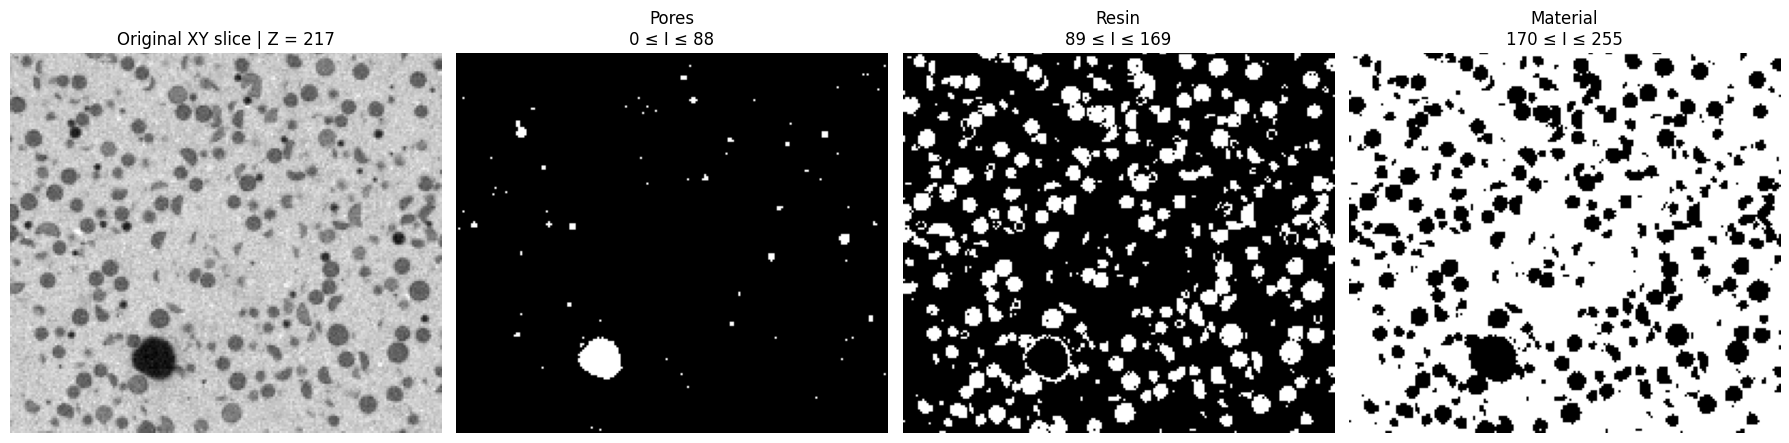

In [64]:
# ============================================================
# Cell 30 - Visualize the 3 selected phases on XY slice
# 4 panels: original + pores + resin + material
# ============================================================

z_vis = z_mid
slice_xy = volume[z_vis]

# Selected thresholds
PORE_MAX = 88
RESIN_MIN = 89
RESIN_MAX = 169
MATERIAL_MIN = 170

# Phase masks
pores_mask_xy = slice_xy <= PORE_MAX
resin_mask_xy = (slice_xy >= RESIN_MIN) & (slice_xy <= RESIN_MAX)
material_mask_xy = slice_xy >= MATERIAL_MIN

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Original slice
axes[0].imshow(slice_xy, cmap="gray")
axes[0].set_title(f"Original XY slice | Z = {z_vis}")
axes[0].axis("off")

# Pores
axes[1].imshow(pores_mask_xy, cmap="gray")
axes[1].set_title("Pores\n0 ≤ I ≤ 88")
axes[1].axis("off")

# Resin
axes[2].imshow(resin_mask_xy, cmap="gray")
axes[2].set_title("Resin\n89 ≤ I ≤ 169")
axes[2].axis("off")

# Material
axes[3].imshow(material_mask_xy, cmap="gray")
axes[3].set_title("Material\n170 ≤ I ≤ 255")
axes[3].axis("off")

plt.tight_layout()
plt.show()

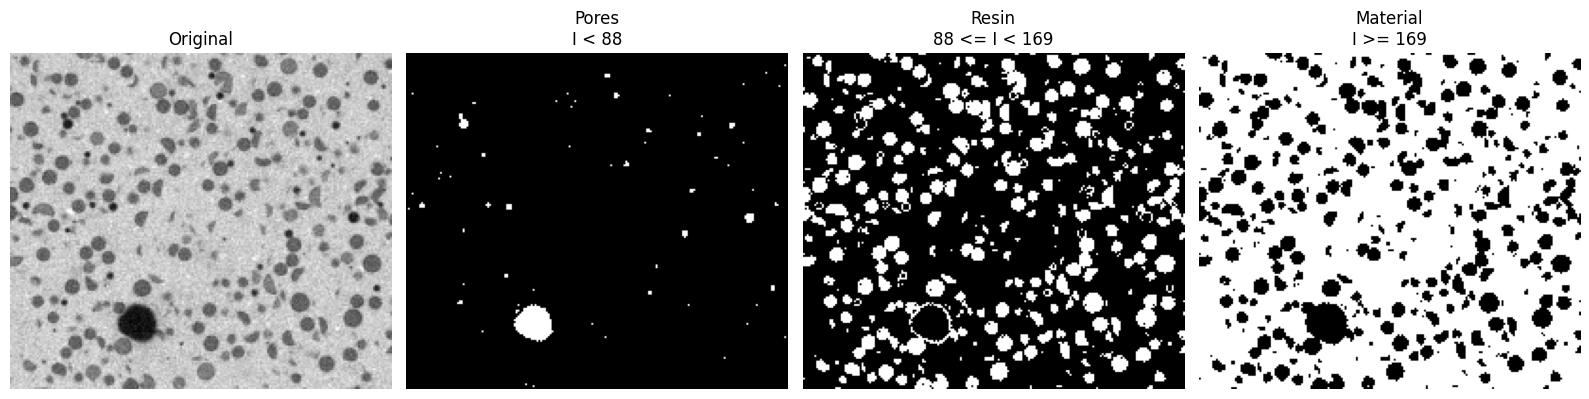

In [65]:
# ============================================================
# Cell 31 - Show individual masks for one threshold set
# ============================================================

# Change these values after visual inspection
PORE_THRESHOLD = 88
RESIN_THRESHOLD = 169

labels_preview = np.digitize(slice_xy, bins=[PORE_THRESHOLD, RESIN_THRESHOLD]).astype(np.uint8)

pores_preview = labels_preview == 0
resin_preview = labels_preview == 1
material_preview = labels_preview == 2

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(slice_xy, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(pores_preview, cmap="gray")
axes[1].set_title(f"Pores\nI < {PORE_THRESHOLD}")
axes[1].axis("off")

axes[2].imshow(resin_preview, cmap="gray")
axes[2].set_title(f"Resin\n{PORE_THRESHOLD} <= I < {RESIN_THRESHOLD}")
axes[2].axis("off")

axes[3].imshow(material_preview, cmap="gray")
axes[3].set_title(f"Material\nI >= {RESIN_THRESHOLD}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

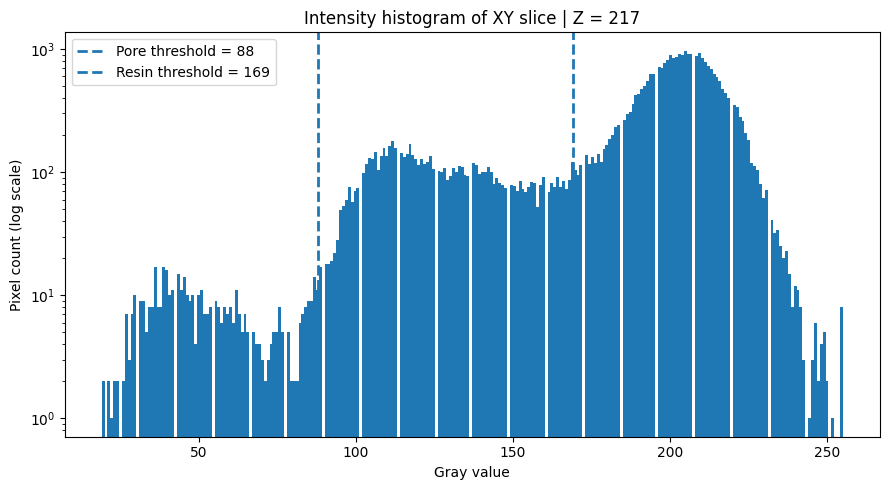

In [66]:
# ============================================================
# Cell 32 - Histogram of XY slice with selected thresholds
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(slice_xy.ravel(), bins=256)
ax.set_yscale("log")

ax.axvline(PORE_THRESHOLD, linestyle="--", linewidth=2, label=f"Pore threshold = {PORE_THRESHOLD}")
ax.axvline(RESIN_THRESHOLD, linestyle="--", linewidth=2, label=f"Resin threshold = {RESIN_THRESHOLD}")

ax.set_title(f"Intensity histogram of XY slice | Z = {z_vis}")
ax.set_xlabel("Gray value")
ax.set_ylabel("Pixel count (log scale)")
ax.legend()

plt.tight_layout()
plt.show()

In [67]:
# ============================================================
# Cell 33 - Create 3-phase segmentation for the full volume
# ============================================================

phase_labels = np.digitize(volume, bins=[PORE_THRESHOLD, RESIN_THRESHOLD]).astype(np.uint8)

print("3-phase volume segmentation created.")
print("Unique labels:", np.unique(phase_labels))
print("0 = pores, 1 = resin, 2 = material")

3-phase volume segmentation created.
Unique labels: [0 1 2]
0 = pores, 1 = resin, 2 = material


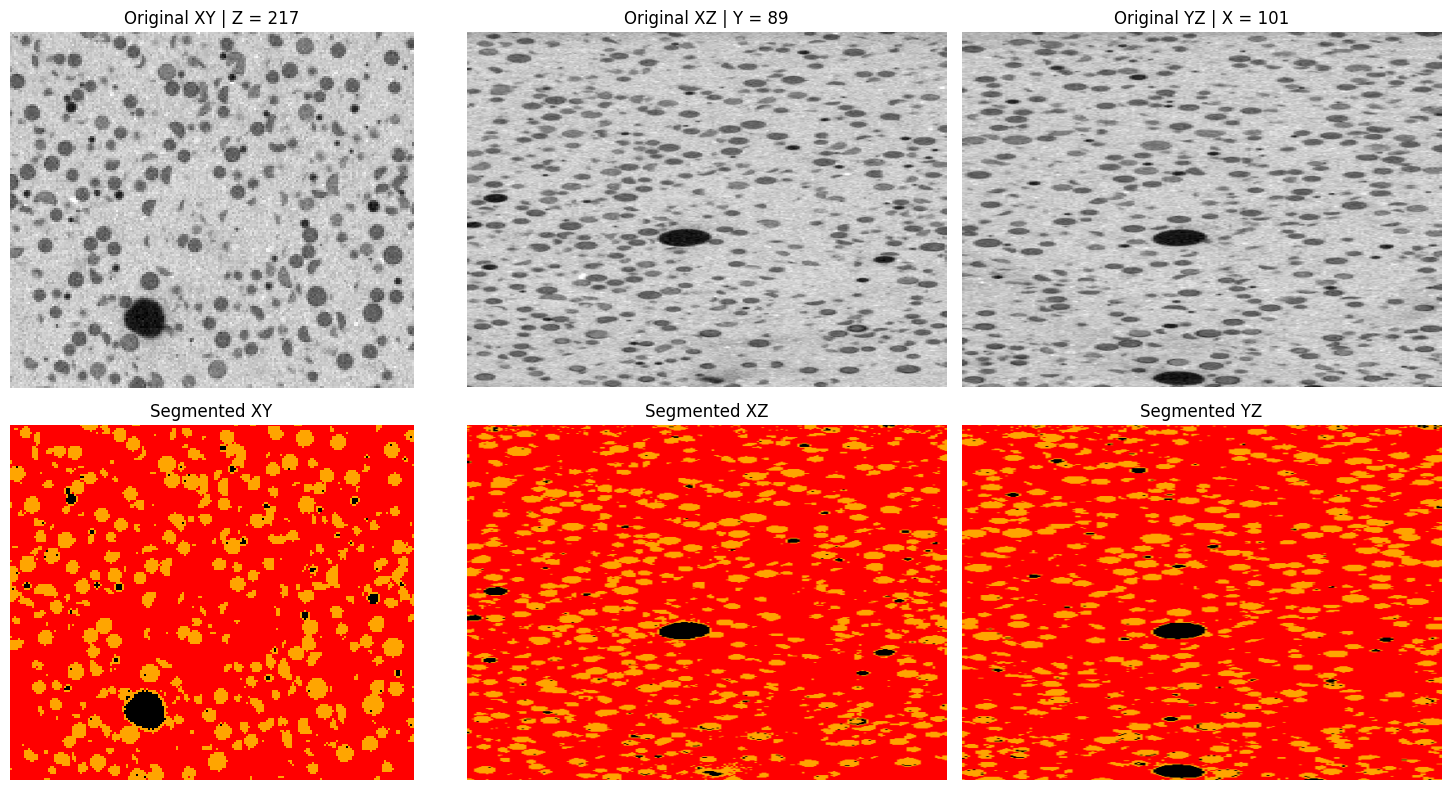

In [68]:
# ============================================================
# Cell 34 - Visualize 3-phase segmentation in orthogonal planes
# ============================================================

xy_phase = phase_labels[z_mid, :, :]
xz_phase = phase_labels[:, y_mid, :]
yz_phase = phase_labels[:, :, x_mid]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Original
axes[0, 0].imshow(volume[z_mid], cmap="gray")
axes[0, 0].set_title(f"Original XY | Z = {z_mid}")
axes[0, 0].axis("off")

axes[0, 1].imshow(volume[:, y_mid, :], cmap="gray", aspect="auto")
axes[0, 1].set_title(f"Original XZ | Y = {y_mid}")
axes[0, 1].axis("off")

axes[0, 2].imshow(volume[:, :, x_mid], cmap="gray", aspect="auto")
axes[0, 2].set_title(f"Original YZ | X = {x_mid}")
axes[0, 2].axis("off")

# Segmented
axes[1, 0].imshow(xy_phase, cmap=phase_cmap, vmin=0, vmax=2)
axes[1, 0].set_title("Segmented XY")
axes[1, 0].axis("off")

axes[1, 1].imshow(xz_phase, cmap=phase_cmap, vmin=0, vmax=2, aspect="auto")
axes[1, 1].set_title("Segmented XZ")
axes[1, 1].axis("off")

axes[1, 2].imshow(yz_phase, cmap=phase_cmap, vmin=0, vmax=2, aspect="auto")
axes[1, 2].set_title("Segmented YZ")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [69]:
# ============================================================
# Cell 35 - Global summary of the 3 phases
# ============================================================

pores_mask = phase_labels == 0
resin_mask = phase_labels == 1
material_mask = phase_labels == 2

phase_summary = pd.DataFrame({
    "phase": ["pores", "resin", "material"],
    "label": [0, 1, 2],
    "voxel_count": [
        pores_mask.sum(),
        resin_mask.sum(),
        material_mask.sum()
    ]
})

phase_summary["volume_fraction"] = phase_summary["voxel_count"] / volume.size
phase_summary["volume_mm3"] = phase_summary["voxel_count"] * voxel_volume_mm3

phase_summary

,phase,label,voxel_count,volume_fraction,volume_mm3
0,pores,0,192848,0.012330,98.738176
1,resin,1,3265945,0.208809,1672.163840
2,material,2,12182067,0.778862,6237.218304


In [70]:
# ============================================================
# Cell 36 - Slice-by-slice phase fractions along Z
# ============================================================

# Masks from the 3-phase segmentation
pores_mask = phase_labels == 0
resin_mask = phase_labels == 1
material_mask = phase_labels == 2

# Slice indices
z_indices = np.arange(z_size)

# Phase fractions per slice
pores_fraction_z = pores_mask.mean(axis=(1, 2))
resin_fraction_z = resin_mask.mean(axis=(1, 2))
material_fraction_z = material_mask.mean(axis=(1, 2))

# Physical Z position
z_position_mm = z_indices * voxel_size_mm

# Build dataframe
df_slice_phase_fractions = pd.DataFrame({
    "z_index": z_indices,
    "z_position_mm": z_position_mm,
    "pores_fraction": pores_fraction_z,
    "resin_fraction": resin_fraction_z,
    "material_fraction": material_fraction_z,
})

# Check that fractions add up to 1
df_slice_phase_fractions["total_fraction"] = (
    df_slice_phase_fractions["pores_fraction"] +
    df_slice_phase_fractions["resin_fraction"] +
    df_slice_phase_fractions["material_fraction"]
)

df_slice_phase_fractions.head()

,z_index,z_position_mm,pores_fraction,resin_fraction,material_fraction,total_fraction
0,0,0.00,0.056875,0.321059,0.622066,1.0
1,1,0.08,0.049366,0.312271,0.638364,1.0
2,2,0.16,0.040800,0.301925,0.657276,1.0
3,3,0.24,0.033513,0.292524,0.673963,1.0
4,4,0.32,0.028952,0.273418,0.697630,1.0


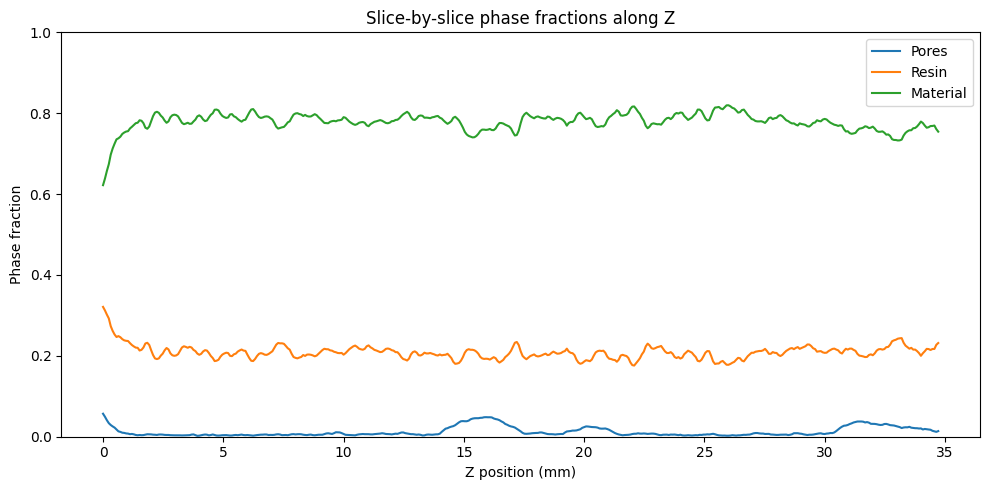

In [71]:
# ============================================================
# Cell 37 - Plot slice-by-slice phase fractions along Z
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["pores_fraction"],
    label="Pores"
)

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["resin_fraction"],
    label="Resin"
)

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["material_fraction"],
    label="Material"
)

ax.set_title("Slice-by-slice phase fractions along Z")
ax.set_xlabel("Z position (mm)")
ax.set_ylabel("Phase fraction")
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.show()

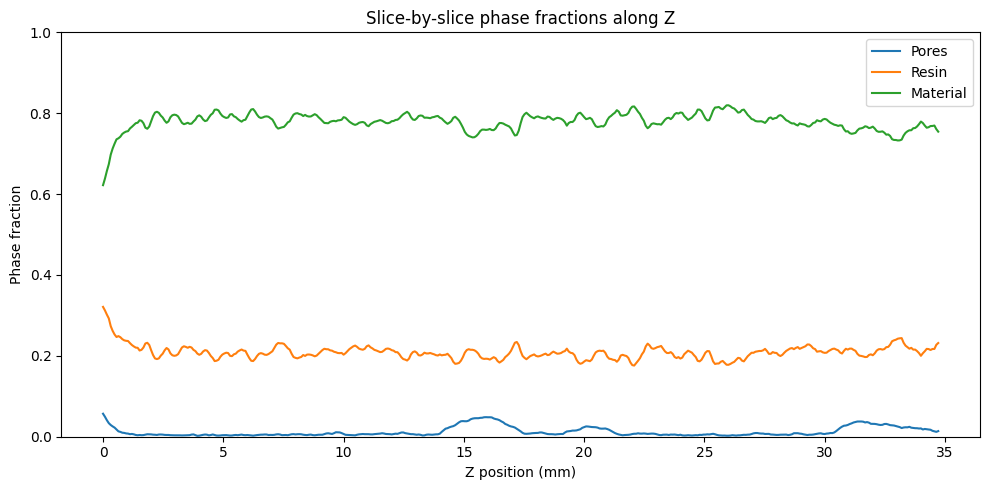

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\figures\phase_fractions_vs_z.png


In [72]:
# ============================================================
# Cell 38 - Save slice-by-slice phase fractions plot
# ============================================================

out_path = FIGURES_DIR / "phase_fractions_vs_z.png"

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["pores_fraction"],
    label="Pores"
)

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["resin_fraction"],
    label="Resin"
)

ax.plot(
    df_slice_phase_fractions["z_position_mm"],
    df_slice_phase_fractions["material_fraction"],
    label="Material"
)

ax.set_title("Slice-by-slice phase fractions along Z")
ax.set_xlabel("Z position (mm)")
ax.set_ylabel("Phase fraction")
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out_path}")

In [73]:
# ============================================================
# Cell 39 - Save slice-by-slice phase fractions table
# ============================================================

out_csv = RESULTS_DIR / "slice_by_slice_phase_fractions.csv"

df_slice_phase_fractions.to_csv(out_csv, index=False)

print(f"Slice-by-slice phase fractions saved to: {out_csv}")

Slice-by-slice phase fractions saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\slice_by_slice_phase_fractions.csv


In [74]:
# ============================================================
# Cell 40 - Descriptive statistics of phase fractions along Z
# ============================================================

fraction_columns = [
    "pores_fraction",
    "resin_fraction",
    "material_fraction"
]

df_phase_fraction_stats = df_slice_phase_fractions[fraction_columns].describe().T

df_phase_fraction_stats["coefficient_of_variation"] = (
    df_phase_fraction_stats["std"] / df_phase_fraction_stats["mean"]
)

df_phase_fraction_stats

,count,mean,std,min,25%,50%,75%,max,coefficient_of_variation
pores_fraction,435.0,0.012330,0.011771,0.002225,0.004728,0.006675,0.017521,0.056875,0.954719
resin_fraction,435.0,0.208809,0.016981,0.175965,0.199675,0.207615,0.216556,0.321059,0.081323
material_fraction,435.0,0.778862,0.022066,0.622066,0.769524,0.781761,0.792051,0.819613,0.028331


In [75]:
"""
The resin and material fractions remain relatively stable along the Z direction, suggesting that the selected subvolume is 
representative in terms of bulk phase distribution. The pore fraction shows higher relative variability, mainly because pores 
occupy a much smaller volume fraction and are more sensitive to local spatial fluctuations.
"""

'\nThe resin and material fractions remain relatively stable along the Z direction, suggesting that the selected subvolume is \nrepresentative in terms of bulk phase distribution. The pore fraction shows higher relative variability, mainly because pores \noccupy a much smaller volume fraction and are more sensitive to local spatial fluctuations.\n'

In [76]:
# ============================================================
# Cell 41 - Save descriptive statistics of phase fractions
# ============================================================

out_csv = RESULTS_DIR / "phase_fraction_descriptive_statistics.csv"

df_phase_fraction_stats.to_csv(out_csv)

print(f"Phase fraction descriptive statistics saved to: {out_csv}")

Phase fraction descriptive statistics saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\phase_fraction_descriptive_statistics.csv


In [80]:
# ============================================================
# Cell 42 - Helper function for 2D connected-component analysis
# Updated for recent scikit-image versions
# ============================================================

def analyze_2d_components(mask_2d, intensity_image_2d, z_index, phase_name, min_area_pixels=5):
    """
    Analyze connected components in a 2D binary mask.

    Parameters
    ----------
    mask_2d : 2D boolean array
        Binary mask for a given phase in one slice.
    intensity_image_2d : 2D array
        Original grayscale image corresponding to the same slice.
    z_index : int
        Slice index along the Z axis.
    phase_name : str
        Name of the analyzed phase.
    min_area_pixels : int
        Minimum object area in pixels to keep.

    Returns
    -------
    list of dict
        One dictionary per connected component.
    """

    labeled_mask = measure.label(mask_2d, connectivity=2)

    props = measure.regionprops(
        labeled_mask,
        intensity_image=intensity_image_2d
    )

    rows = []

    for prop in props:
        if prop.area < min_area_pixels:
            continue

        area_pixels = prop.area
        area_mm2 = area_pixels * (voxel_size_mm ** 2)

        perimeter = prop.perimeter

        if perimeter > 0:
            circularity = 4 * np.pi * area_pixels / (perimeter ** 2)
        else:
            circularity = np.nan

        major_axis = prop.axis_major_length
        minor_axis = prop.axis_minor_length

        if minor_axis > 0:
            aspect_ratio = major_axis / minor_axis
        else:
            aspect_ratio = np.nan

        centroid_y, centroid_x = prop.centroid

        equivalent_diameter_pixels = prop.equivalent_diameter_area

        rows.append({
            "phase": phase_name,
            "z_index": z_index,
            "z_position_mm": z_index * voxel_size_mm,
            "label_2d": prop.label,
            "area_pixels": area_pixels,
            "area_mm2": area_mm2,
            "equivalent_diameter_pixels": equivalent_diameter_pixels,
            "equivalent_diameter_um": equivalent_diameter_pixels * VOXEL_SIZE_UM,
            "perimeter_pixels": perimeter,
            "circularity": circularity,
            "eccentricity": prop.eccentricity,
            "major_axis_length_pixels": major_axis,
            "minor_axis_length_pixels": minor_axis,
            "aspect_ratio": aspect_ratio,
            "solidity": prop.solidity,
            "extent": prop.extent,
            "centroid_y_pixels": centroid_y,
            "centroid_x_pixels": centroid_x,
            "centroid_y_mm": centroid_y * voxel_size_mm,
            "centroid_x_mm": centroid_x * voxel_size_mm,
            "mean_intensity": prop.intensity_mean,
            "min_intensity": prop.intensity_min,
            "max_intensity": prop.intensity_max,
        })

    return rows

In [81]:
# ============================================================
# Cell 43 - Test 2D component analysis on one representative slice
# ============================================================

z_test = z_mid

pores_slice = pores_mask[z_test]
resin_slice = resin_mask[z_test]

rows_pores_test = analyze_2d_components(
    mask_2d=pores_slice,
    intensity_image_2d=volume[z_test],
    z_index=z_test,
    phase_name="pores",
    min_area_pixels=5
)

rows_resin_test = analyze_2d_components(
    mask_2d=resin_slice,
    intensity_image_2d=volume[z_test],
    z_index=z_test,
    phase_name="resin",
    min_area_pixels=5
)

df_components_2d_test = pd.DataFrame(rows_pores_test + rows_resin_test)

print("Number of 2D components in test slice:", len(df_components_2d_test))
df_components_2d_test.head()

Number of 2D components in test slice: 228


,phase,z_index,z_position_mm,label_2d,area_pixels,area_mm2,equivalent_diameter_pixels,equivalent_diameter_um,perimeter_pixels,circularity,...,aspect_ratio,solidity,extent,centroid_y_pixels,centroid_x_pixels,centroid_y_mm,centroid_x_mm,mean_intensity,min_intensity,max_intensity
0,pores,217,17.36,3,6.0,0.0384,2.763953,221.116256,6.000000,2.094395,...,1.632993,1.00000,1.000000,11.500000,106.000000,0.920000,8.480000,60.500000,39.0,86.0
1,pores,217,17.36,8,7.0,0.0448,2.985411,238.832853,6.828427,1.886542,...,1.080123,1.00000,0.777778,22.000000,110.714286,1.760000,8.857143,57.000000,29.0,70.0
2,pores,217,17.36,14,26.0,0.1664,5.753627,460.290191,19.656854,0.845581,...,1.915440,0.83871,0.650000,36.115385,29.730769,2.889231,2.378462,61.653846,34.0,86.0
3,pores,217,17.36,16,8.0,0.0512,3.191538,255.323059,7.414214,1.828815,...,1.264911,1.00000,0.888889,37.875000,171.875000,3.030000,13.750000,58.875000,48.0,70.0
4,pores,217,17.36,17,5.0,0.0320,2.523133,201.850602,5.207107,2.317325,...,1.732051,1.00000,0.833333,40.600000,127.800000,3.248000,10.224000,66.000000,57.0,84.0


In [82]:
# ============================================================
# Cell 44 - Summary of 2D components in the test slice
# ============================================================

df_components_2d_test.groupby("phase").agg(
    number_of_objects=("label_2d", "count"),
    mean_area_pixels=("area_pixels", "mean"),
    median_area_pixels=("area_pixels", "median"),
    mean_equivalent_diameter_um=("equivalent_diameter_um", "mean"),
    median_equivalent_diameter_um=("equivalent_diameter_um", "median"),
    mean_circularity=("circularity", "mean"),
    mean_aspect_ratio=("aspect_ratio", "mean"),
    mean_intensity=("mean_intensity", "mean")
)

,number_of_objects,mean_area_pixels,median_area_pixels,mean_equivalent_diameter_um,median_equivalent_diameter_um,mean_circularity,mean_aspect_ratio,mean_intensity
phase,,,,,,,,
pores,15,27.533333,7.0,344.216537,238.832853,1.793112,1.358587,61.328747
resin,213,34.816901,26.0,489.145938,460.290191,1.224295,1.608523,132.508384


In [83]:
# ============================================================
# Cell 45 - Run 2D connected-component analysis on all slices
# ============================================================

all_components_2d = []

MIN_AREA_PIXELS_2D = 5

for z in range(z_size):
    # Binary masks for current slice
    pores_slice = pores_mask[z]
    resin_slice = resin_mask[z]
    
    # Original intensity slice
    intensity_slice = volume[z]
    
    # Analyze pores
    rows_pores = analyze_2d_components(
        mask_2d=pores_slice,
        intensity_image_2d=intensity_slice,
        z_index=z,
        phase_name="pores",
        min_area_pixels=MIN_AREA_PIXELS_2D
    )
    
    # Analyze resin
    rows_resin = analyze_2d_components(
        mask_2d=resin_slice,
        intensity_image_2d=intensity_slice,
        z_index=z,
        phase_name="resin",
        min_area_pixels=MIN_AREA_PIXELS_2D
    )
    
    all_components_2d.extend(rows_pores)
    all_components_2d.extend(rows_resin)

df_components_2d = pd.DataFrame(all_components_2d)

print("2D connected-component analysis completed.")
print("Total number of 2D components:", len(df_components_2d))
print("Analyzed slices:", z_size)

df_components_2d.head()

2D connected-component analysis completed.
Total number of 2D components: 91613
Analyzed slices: 435


,phase,z_index,z_position_mm,label_2d,area_pixels,area_mm2,equivalent_diameter_pixels,equivalent_diameter_um,perimeter_pixels,circularity,...,aspect_ratio,solidity,extent,centroid_y_pixels,centroid_x_pixels,centroid_y_mm,centroid_x_mm,mean_intensity,min_intensity,max_intensity
0,pores,0,0.0,1,7.0,0.0448,2.985411,238.832853,5.207107,3.244255,...,2.096953,0.875000,0.583333,0.571429,119.000000,0.045714,9.520000,82.857143,79.0,87.0
1,pores,0,0.0,2,18.0,0.1152,4.787307,382.984589,14.899495,1.018918,...,1.280274,0.782609,0.600000,1.666667,187.500000,0.133333,15.000000,78.444444,69.0,87.0
2,pores,0,0.0,4,24.0,0.1536,5.527906,442.232511,19.035534,0.832321,...,2.309641,0.615385,0.533333,3.291667,65.625000,0.263333,5.250000,64.166667,27.0,87.0
3,pores,0,0.0,5,52.0,0.3328,8.136858,650.948631,38.935029,0.431055,...,1.666862,0.547368,0.337662,8.288462,149.000000,0.663077,11.920000,80.288462,65.0,87.0
4,pores,0,0.0,7,34.0,0.2176,6.579525,526.361971,27.278175,0.574193,...,1.084207,0.693878,0.531250,8.294118,7.352941,0.663529,0.588235,79.911765,59.0,87.0


In [84]:
# ============================================================
# Cell 46 - Global summary of 2D components by phase
# ============================================================

df_components_2d_summary = df_components_2d.groupby("phase").agg(
    number_of_objects=("label_2d", "count"),
    mean_area_pixels=("area_pixels", "mean"),
    median_area_pixels=("area_pixels", "median"),
    std_area_pixels=("area_pixels", "std"),
    mean_equivalent_diameter_um=("equivalent_diameter_um", "mean"),
    median_equivalent_diameter_um=("equivalent_diameter_um", "median"),
    std_equivalent_diameter_um=("equivalent_diameter_um", "std"),
    mean_circularity=("circularity", "mean"),
    median_circularity=("circularity", "median"),
    mean_eccentricity=("eccentricity", "mean"),
    mean_aspect_ratio=("aspect_ratio", "mean"),
    median_aspect_ratio=("aspect_ratio", "median"),
    mean_solidity=("solidity", "mean"),
    mean_intensity=("mean_intensity", "mean"),
    median_intensity=("mean_intensity", "median")
)

df_components_2d_summary

,number_of_objects,mean_area_pixels,median_area_pixels,std_area_pixels,mean_equivalent_diameter_um,median_equivalent_diameter_um,std_equivalent_diameter_um,mean_circularity,median_circularity,mean_eccentricity,mean_aspect_ratio,median_aspect_ratio,mean_solidity,mean_intensity,median_intensity
phase,,,,,,,,,,,,,,,
pores,5280,29.560417,9.0,116.130957,362.344433,270.811000,331.069805,1.804694,1.617036,0.555469,1.495910,1.224745,0.915935,64.928671,63.375000
resin,86333,36.813872,27.0,35.775384,499.255427,469.058411,225.235480,1.240806,1.109758,0.666057,1.658923,1.464334,0.863796,133.814264,132.846154


In [85]:
# ============================================================
# Cell 47 - Number of 2D objects per slice
# ============================================================

df_objects_per_slice = (
    df_components_2d
    .groupby(["z_index", "z_position_mm", "phase"])
    .size()
    .reset_index(name="number_of_objects")
)

df_objects_per_slice.head()

,z_index,z_position_mm,phase,number_of_objects
0,0,0.00,pores,106
1,0,0.00,resin,178
2,1,0.08,pores,97
3,1,0.08,resin,194
4,2,0.16,pores,79


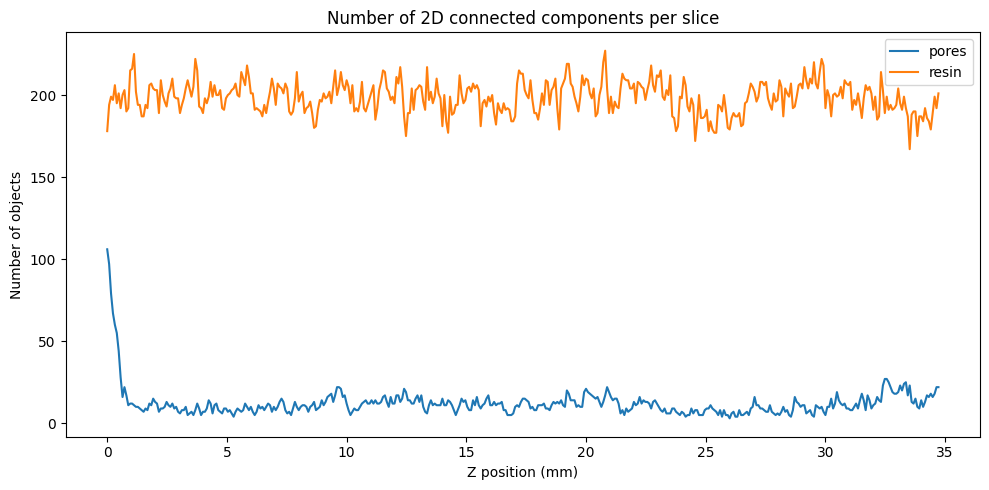

In [86]:
# ============================================================
# Cell 48 - Plot number of 2D objects per slice
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

for phase in df_objects_per_slice["phase"].unique():
    df_phase = df_objects_per_slice[df_objects_per_slice["phase"] == phase]
    
    ax.plot(
        df_phase["z_position_mm"],
        df_phase["number_of_objects"],
        label=phase
    )

ax.set_title("Number of 2D connected components per slice")
ax.set_xlabel("Z position (mm)")
ax.set_ylabel("Number of objects")
ax.legend()

plt.tight_layout()
plt.show()

In [87]:
# ============================================================
# Cell 49 - Save 2D connected-component table
# ============================================================

out_csv = RESULTS_DIR / "components_2d_slice_by_slice.csv"

df_components_2d.to_csv(out_csv, index=False)

print(f"2D connected-component table saved to: {out_csv}")

2D connected-component table saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\components_2d_slice_by_slice.csv


In [88]:
# ============================================================
# Cell 50 - Save 2D connected-component summary
# ============================================================

out_csv = RESULTS_DIR / "components_2d_summary_by_phase.csv"

df_components_2d_summary.to_csv(out_csv)

print(f"2D connected-component summary saved to: {out_csv}")

2D connected-component summary saved to: C:\Users\Peter\ai-imaging-portfolio\projects\02_microct_subvolume_3d_analysis\results\components_2d_summary_by_phase.csv


In [89]:
print("VOXEL_SIZE_UM:", VOXEL_SIZE_UM)
print("voxel_size_mm:", voxel_size_mm)
print("voxel_volume_mm3:", voxel_volume_mm3)

VOXEL_SIZE_UM: 80.0
voxel_size_mm: 0.08
voxel_volume_mm3: 0.0005120000000000001
